In [1]:
import pandas as pd
import wandb
from scipy import stats

wandb.login(key="cf344975eb80edf6f0d52af80528cc6094234caf")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /home/rahul/.netrc
wandb: Currently logged in as: rahul-e-dev to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [2]:
api = wandb.Api()
runs = api.runs("rahul-e-dev/evaluate_all_v4")

In [3]:
cols = [
    'outer', 
    'inner', 
    'average_precision', 
    'roc_auc',
    'accuracy', 
    'balanced_accuracy', 
    'precision', 
    'recall',
    'f1', 
    'mcc',
    'dataset',
    'split_type',
    'model'
]

In [4]:
records = []
for run in runs:
    df = pd.DataFrame.from_records(list(run.scan_history()))
    # df['name'] = run.name
    tags = run.tags
    if any([x.endswith("feat") for x in tags]):
        df["model"] = df["model"] + "-feat"
    
    records.append(df)


df_full = pd.concat(records).loc[:, cols]

# df = pd.concat([
#     pd.DataFrame.from_records(list(run.scan_history()))
#     for run in runs
# ]).loc[:, cols]

In [5]:
metrics = [
    # 'outer', 
    # 'inner', 
    'average_precision', 
    'roc_auc',
    # 'accuracy', 
    # 'balanced_accuracy', 
    'precision', 
    'recall',
    'f1', 
    'mcc',
    # 'dataset',
    # 'split_type',
    # 'model'
]

In [7]:
from stats_utils import (
    make_boxplots_nonparametric,
    make_boxplots_parametric,
    make_ci_plot_grid,
    make_mcs_plot_grid,
    make_normality_diagnostic,
    rm_tukey_hsd,
    make_critical_difference_diagrams,
    make_sign_plots_nonparametric
)


# make_normality_diagnostic(df.query("dataset == 'DB_MALARIA'").copy(), metrics)

In [8]:
df = df_full.copy()

df['cv_cycle'] = df['outer'] * 5 + df['inner']

df = df.rename({
    'model': 'method',
    'split': 'split_type'
}, axis=1)

df.loc[df['method'] == 'baseline', 'method'] = 'chemprop'
df.loc[df['method'] == 'baseline-feat', 'method'] = 'chemprop-feat'

In [35]:
df['method'].unique()

array(['deltaprop-feat', 'deltaprop', 'chemprop', 'chemprop-feat',
       'xgboost-feat', 'deltaprop-btl', 'deltaprop-btl2'], dtype=object)

In [70]:
asd = df[df["split_type"] == "random"]
asd = asd[asd['dataset'] == "GSK_HEPG2"]
asd = asd[asd['method'].isin(['chemprop', 'deltaprop', 'deltaprop-feat', 'chemprop-feat', 'xgboost-feat'])]
asd = asd.sort_values(by=['method', 'cv_cycle'])

asd['method'] = asd['method'].replace({
    'chemprop': 'cp',
    'chemprop-feat': 'cp-f',
    'deltaprop': 'dp',
    'deltaprop-feat': 'dp-f',
    'xgboost-feat': 'xgb-f',
    # 'deltaprop-btl': 'dbtl'
})
asd["method"].value_counts()

method
cp       25
cp-f     25
dp       25
dp-f     25
xgb-f    25
Name: count, dtype: int64

In [71]:
for metric in metrics:
    groups = asd.groupby('method')[metric].apply(list)
    stat, pvalue = stats.levene(*groups)
    print(f'Levene test for {metric}: p-value = {pvalue}')

Levene test for average_precision: p-value = 0.6604391991814857
Levene test for roc_auc: p-value = 0.47578011982330637
Levene test for precision: p-value = 0.0008880220902278098
Levene test for recall: p-value = 0.00451426498647108
Levene test for f1: p-value = 0.20745185187470783
Levene test for mcc: p-value = 0.31696012385877004


In [72]:
variances_by_method = asd.groupby('method')[metrics].var()
max_fold_diff = variances_by_method.max() / variances_by_method.min()
print(max_fold_diff)

average_precision     3.605056
roc_auc               8.336251
precision            11.983121
recall                3.608157
f1                    5.611627
mcc                   5.534717
dtype: float64


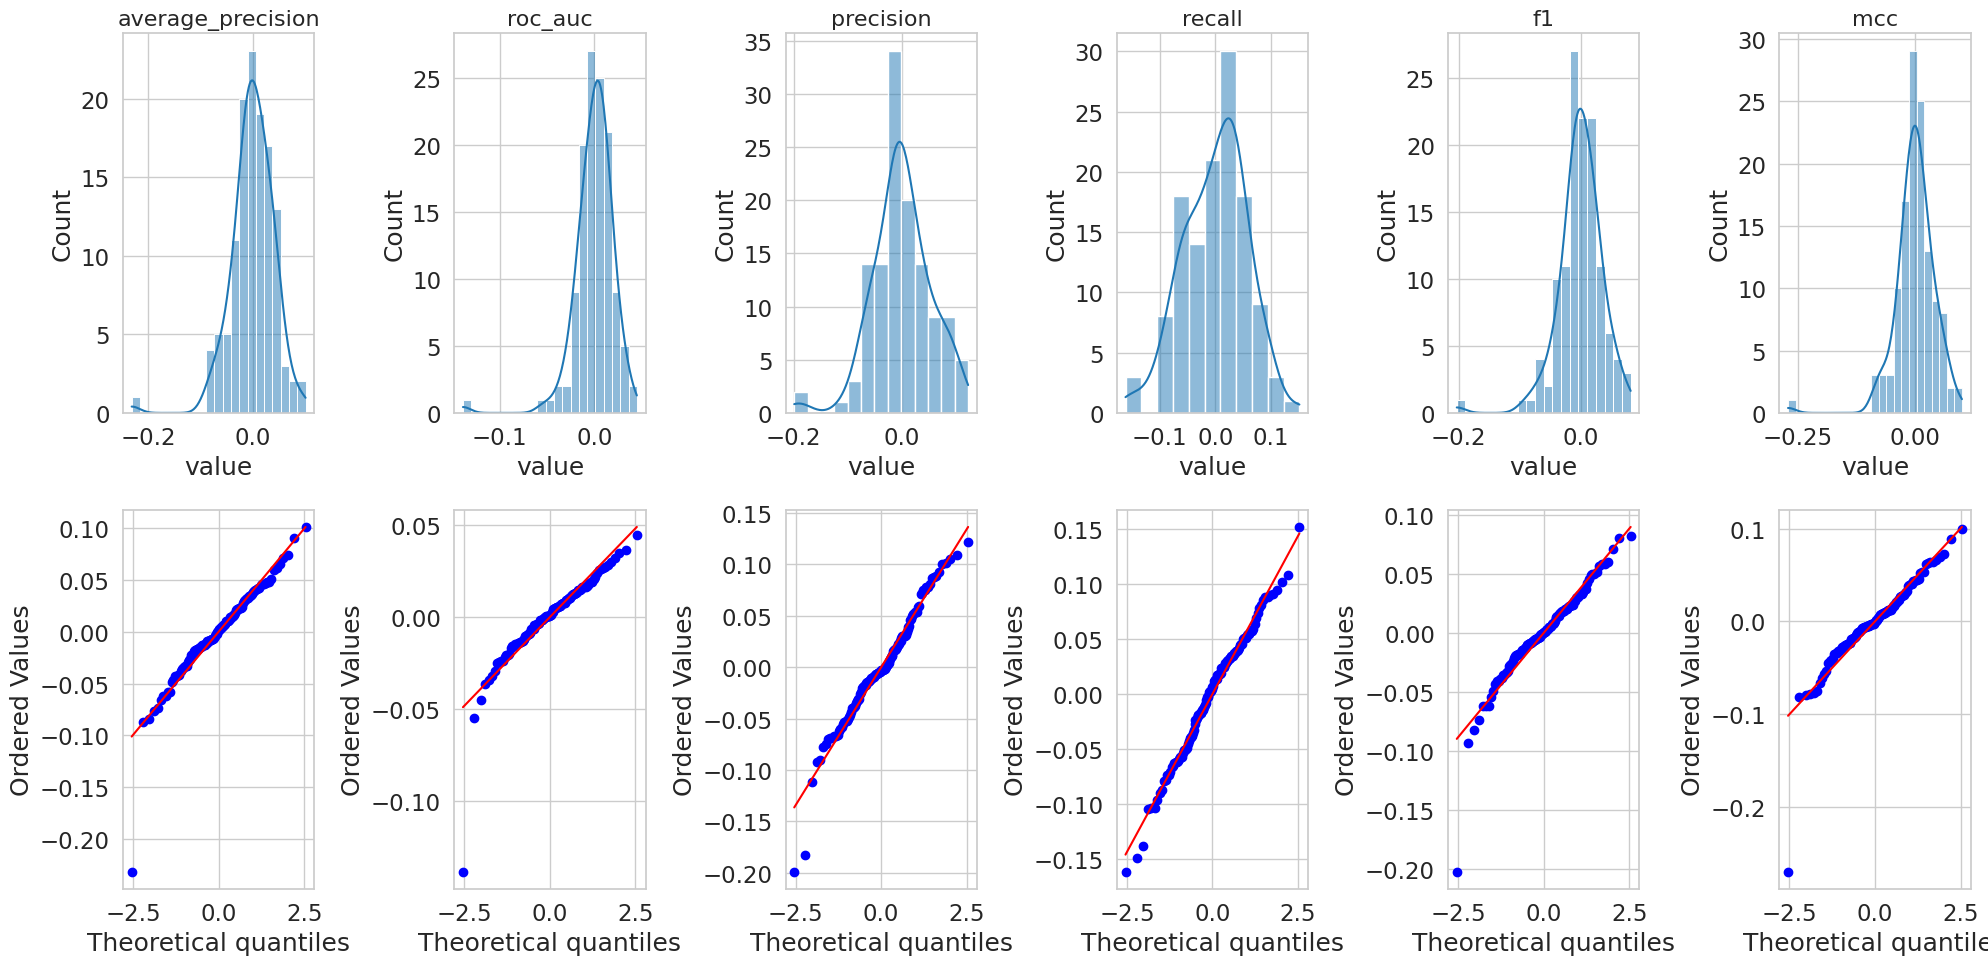

In [73]:
make_normality_diagnostic(asd.copy(), metrics)

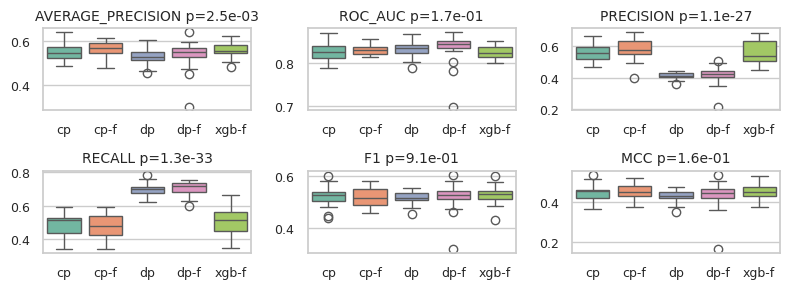

In [74]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'axes.labelsize': 8,    # Font size of the x and y labels
    'xtick.labelsize': 9,   # Font size of the x-axis tick labels
    'ytick.labelsize': 9,   # Font size of the y-axis tick labels
    'axes.titlesize': 10,    # Font size of the subplot titles
    'font.size': 10          # Default font size for other text elements
})

fig, axes = make_boxplots_parametric(asd, metrics, figsize=(8, 3))

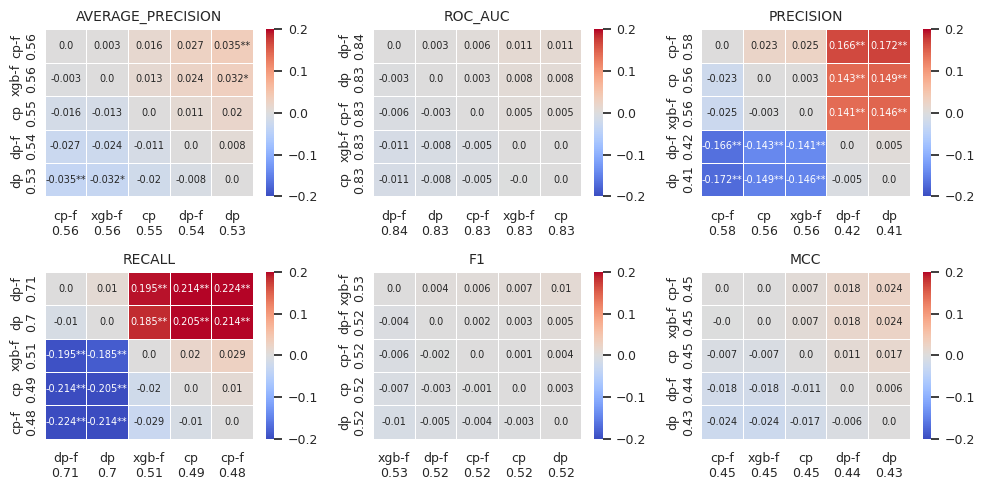

In [75]:
effect_dict = {m: 0.1 for m in metrics}
direction_dict = {m: "maximize" for m in metrics}

make_mcs_plot_grid(asd, metrics, group_col="method", effect_dict=effect_dict, direction_dict=direction_dict,
                   figsize=(10, 5), cell_text_size=7, axis_text_size=9, title_text_size=10, show_diff=True, sort_axes=True)

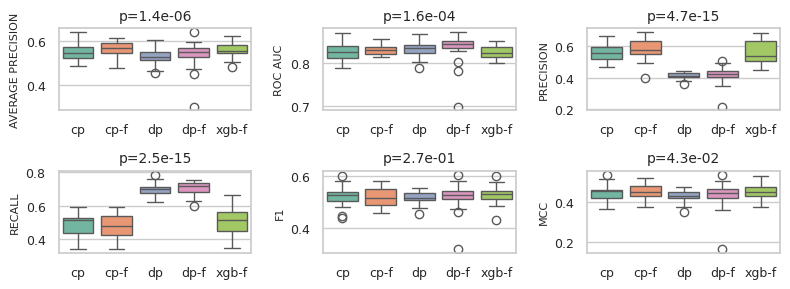

In [76]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'axes.labelsize': 8,    # Font size of the x and y labels
    'xtick.labelsize': 9,   # Font size of the x-axis tick labels
    'ytick.labelsize': 9,   # Font size of the y-axis tick labels
    'axes.titlesize': 10,    # Font size of the subplot titles
    'font.size': 10          # Default font size for other text elements
})

make_boxplots_nonparametric(asd, metrics, figsize=(8, 3))

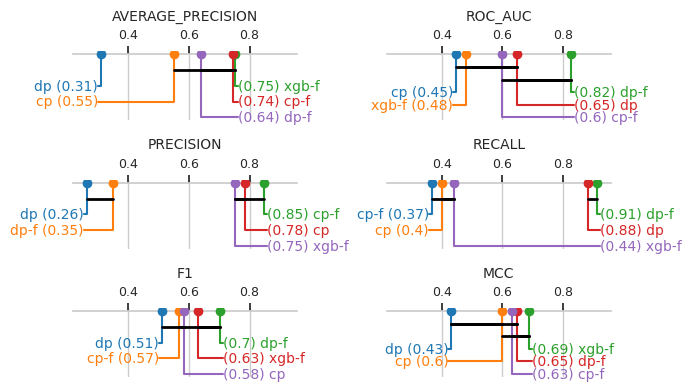

In [77]:
make_critical_difference_diagrams(asd.copy(), metrics, figsize=(7, 4))

In [18]:
# make_sign_plots_nonparametric(asd.copy(), metrics)

In [19]:
# make_ci_plot_grid(asd.copy(), metrics, "method")

In [20]:
for metric in metric_ls:
    groups = fin_df.groupby('method')[metric].apply(list)
    stat, pvalue = stats.levene(*groups)
    print(f'Levene test for {metric}: p-value = {pvalue}')

NameError: name 'metric_ls' is not defined

In [ ]:
variances_by_method = fin_df.groupby('method')[metric_ls].var()
max_fold_diff = variances_by_method.max() / variances_by_method.min()
print(max_fold_diff)

In [ ]:
make_boxplots_parametric(fin_df.copy(), metric_ls)

In [ ]:
effect_dict = {m: 0.1 for m in metric_ls}
direction_dict = {m: "maximize" for m in metric_ls} 

make_mcs_plot_grid(fin_df, metric_ls, group_col="method", effect_dict=effect_dict, direction_dict=direction_dict,
                   figsize=(22, 14), cell_text_size=20, axis_text_size=18, title_text_size=26, show_diff=True, sort_axes=True)

In [ ]:
for i, metric in enumerate(metric_ls):
    df_tukey, _, _, _ = rm_tukey_hsd(fin_df, metric, group_col="method")
    print(df_tukey)

In [ ]:
df_tukey

In [ ]:
make_ci_plot_grid(fin_df, metric_ls, "method")

In [ ]:
import pandas as pd
import pingouin as pg

df = pd.DataFrame({
    'white': {0: 10, 1: 8, 2: 7, 3: 9, 4: 7, 5: 4, 6: 5, 7: 6, 8: 5, 9: 10, 10: 4, 11: 7},
    'red': {0: 7, 1: 5, 2: 8, 3: 6, 4: 5, 5: 7, 6: 9, 7: 6, 8: 4, 9: 6, 10: 7, 11: 3},
    'rose': {0: 8, 1: 5, 2: 6, 3: 4, 4: 7, 5: 5, 6: 3, 7: 7, 8: 6, 9: 4, 10: 4, 11: 3}})
pg.friedman(df)